In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.float_format = '{:,.2f}'.format

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [5]:
segment_summary=df.groupby('segment')[['sales','profit']].sum().reset_index()
segment_summary

,segment,sales,profit
0,Consumer,"1,161,401.34","134,119.21"
1,Corporate,"706,146.37","91,979.13"
2,Home Office,"429,653.15","60,298.68"


C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_32700\1927828856.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary,x='segment',y='sales',palette='Set2')


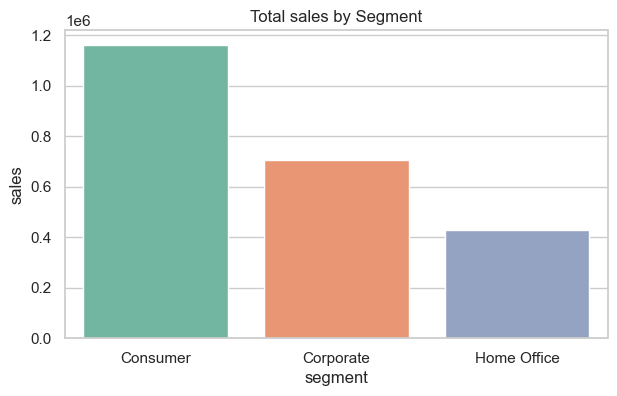

In [6]:
plt.figure(figsize=(7,4))
sns.barplot(data=segment_summary,x='segment',y='sales',palette='Set2')
plt.title('Total sales by Segment')
plt.savefig('../visuals/total_sales_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

Consumer dominates with ~1.16M in sales — nearly double Corporate (706K) and almost triple Home Office (430K). This is expected since Consumer is the largest customer base by order count.

C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_32700\277567814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary,x='segment',y='profit',palette='Set1')


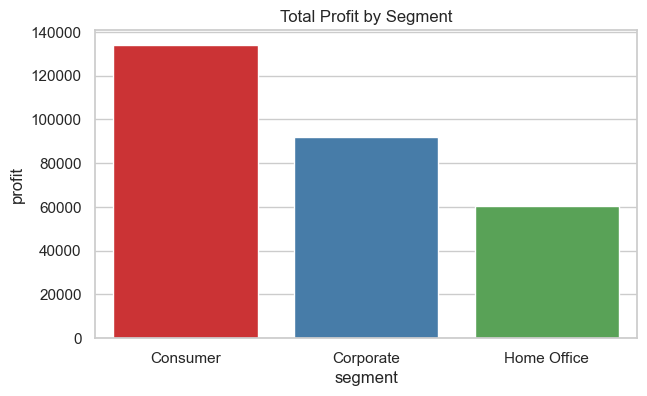

In [9]:
plt.figure(figsize=(7,4))
sns.barplot(data=segment_summary,x='segment',y='profit',palette='Set1')
plt.title('Total Profit by Segment')
plt.savefig('../visuals/total_profit_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

All 3 segments are profitable. Consumer leads at ~134K, Corporate at ~92K, Home Office at ~60K. The profit split roughly follows the sales split — no segment is unusually inefficient.

C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_32700\4129914018.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segment', y='profit', palette='pastel',flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5))


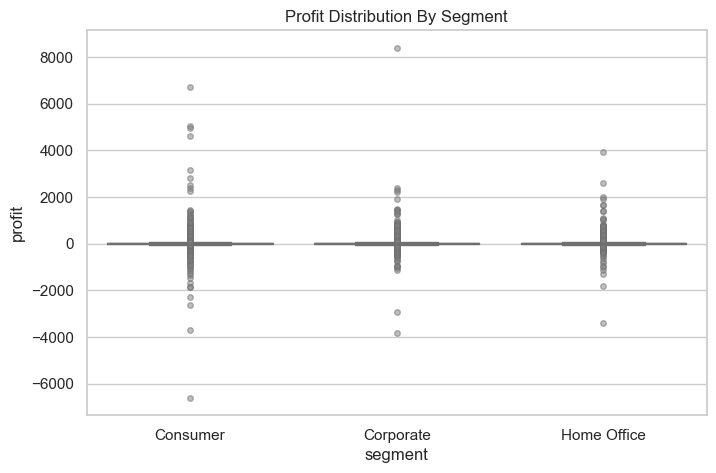

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='segment', y='profit', palette='pastel',flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5))
plt.title('Profit Distribution By Segment')
plt.savefig('../visuals/profit_distribution_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

All 3 segments have their median near zero profit — meaning a typical single order doesn't make much

Consumer has the most extreme outliers — both highest profit (~6700) and worst loss (~-6700)

Corporate has one standout high-profit order (~8300) — likely a bulk tech purchase

All segments have loss-making orders, confirming the discount issue cuts across all customer types